### 1- Setup

In [1]:
!pip install mip

from mip import *
import math


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# resolve o modelo e mostra os valores das variáveis na solução
def solve(model):
  status = model.optimize(max_seconds=15)

  if status != OptimizationStatus.OPTIMAL:
    return

  print("Status = ", status)
  print(f"Solution value  = {model.objective_value:.2f}\n")

  print("Solution:")
  for v in model.vars:
      print(f"{v.name} = {v.x:.2f}")


# salva modelo em arquivo lp, e mostra o conteúdo
def save(model, filename):
  model.write(filename) # salva modelo em arquivo
  with open(filename, "r") as f: # lê e exibe conteúdo do arquivo
    print(f.read())

### 2- Definindo problema

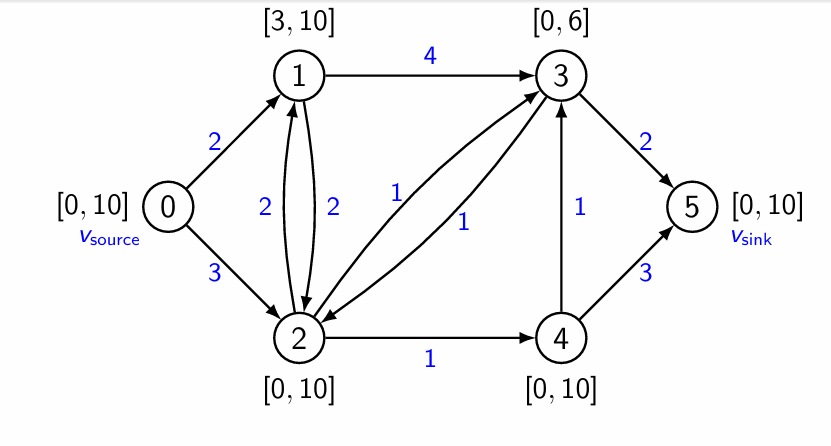

In [3]:
arcs = {
  'A': {'B', 'C'},
  'B': {'C', 'D'},
  'C': {'B', 'D', 'E'},
  'D': {'C', 'F'},
  'E': {'F'},
  'F': {},
}

resource_cost = {
  'A': {'B': 2, 'C': 3},
  'B': {'C': 2, 'D': 4},
  'C': {'B': 2, 'D': 1, 'E': 1},
  'D': {'C': 1, 'F': 2},
  'E': {'F': 3},
  'F': {},
}

costs = {
  'A': {'B': 2, 'C': 3},
  'B': {'C': 2, 'D': 4},
  'C': {'B': 2, 'D': 1, 'E': 1},
  'D': {'C': 1, 'F': 2},
  'E': {'F': 3},
  'F': {},
}

# costs = {
#   'A': {'B': -1, 'C': -1},
#   'B': {'C': -1, 'D': -1},
#   'C': {'B': -1, 'D': -1, 'E': -1},
#   'D': {'C': -1, 'F': -1},
#   'E': {'F': -1},
#   'F': {},
# }

lb = {
  'A': 0,
  'B': 3,
  'C': 0,
  'D': 0,
  'E': 0,
  'F': 0,
}

ub = {
  'A': 10,
  'B': 10,
  'C': 10,
  'D': 6,
  'E': 10,
  'F': 10,
}

# ub = {
#   'A': 20,
#   'B': 20,
#   'C': 20,
#   'D': 20,
#   'E': 20,
#   'F': 20,
# }

ng_set = {
  'A': {},
  'B': {'B', 'C', 'D'},
  'C': {'B', 'C', 'D', 'E'},
  'D': {'B', 'C', 'D', 'E'},
  'E': {'C'},
  'F': {},
}

# ng_set = {
#   'A': {},
#   'B': {},
#   'C': {},
#   'D': {},
#   'E': {},
#   'F': {},
# }

source = 'A'
sink = 'F'

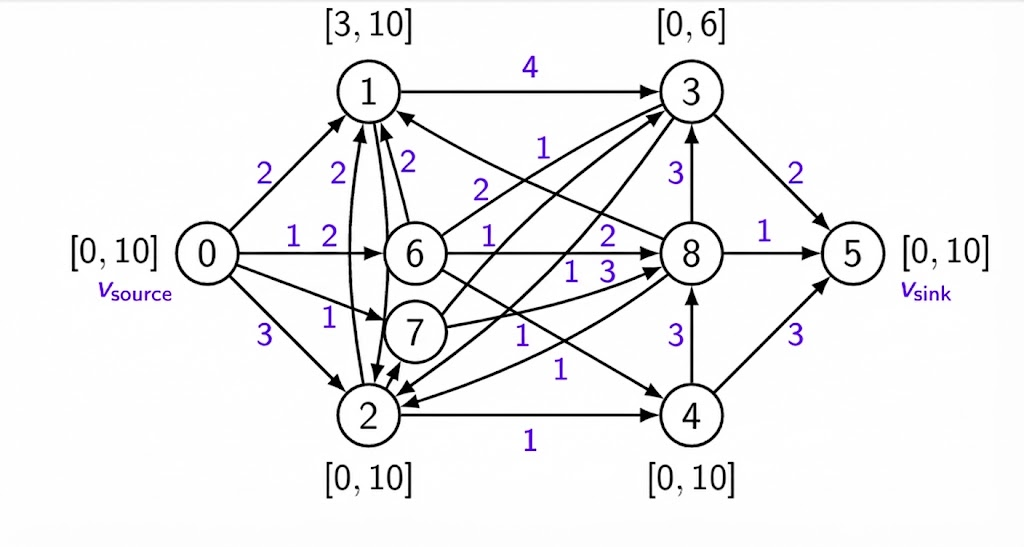

In [4]:
arcs = {
    'A': {'B', 'C', 'G', 'H'},
    'B': {'C', 'D', 'I'},
    'C': {'B', 'E'},
    'D': {'C', 'F'},
    'E': {'D', 'F'},
    'F': {},
    'G': {'B', 'C', 'I'},
    'H': {'C', 'D', 'I'},
    'I': {'D', 'E', 'F'}
}

resource_cost = {
    'A': {'B': 2, 'C': 3, 'G': 1, 'H': 1},
    'B': {'C': 2, 'D': 4, 'I': 2},
    'C': {'B': 2, 'E': 1},
    'D': {'C': 1, 'F': 2},
    'E': {'D': 3, 'F': 3},
    'F': {},
    'G': {'B': 2, 'C': 1, 'I': 1},
    'H': {'C': 2, 'D': 1, 'I': 3},
    'I': {'D': 3, 'E': 3, 'F': 1}
}

# costs = {
#     'A': {'B': 2, 'C': 3, 'G': 1, 'H': 1},
#     'B': {'C': 2, 'D': 4, 'I': 2},
#     'C': {'B': 2, 'E': 1},
#     'D': {'C': 1, 'F': 2},
#     'E': {'D': 3, 'F': 3},
#     'F': {},
#     'G': {'B': 2, 'C': 1, 'I': 1},
#     'H': {'C': 2, 'D': 1, 'I': 3},
#     'I': {'D': 3, 'E': 3, 'F': 1}
# }

costs = {
    'A': {'B': 2, 'C': 3, 'G': 10, 'H': 1},
    'B': {'C': -1, 'D': 4, 'I': 2},
    'C': {'B': -1, 'E': 1},
    'D': {'C': 1, 'F': 2},
    'E': {'D': 3, 'F': 3},
    'F': {},
    'G': {'B': 2, 'C': 1, 'I': 1},
    'H': {'C': 2, 'D': 1, 'I': 3},
    'I': {'D': 3, 'E': 3, 'F': 1}
}

lb = {
    'A': 0, 'B': 3, 'C': 0, 'D': 0, 'E': 0, 
    'F': 0, 'G': 0, 'H': 0, 'I': 0
}

ub = {
    'A': 10, 'B': 10, 'C': 10, 'D': 6, 'E': 10, 
    'F': 10, 'G': 10, 'H': 10, 'I': 10
}

ng_set = {
  'A': {},
  'B': {},
  'C': {}, #'B' ja quebra o loop
  'D': {},
  'E': {},
  'F': {},
  'G': {},
  'H': {},
  'I': {}
}

source = 'A'
sink = 'F'

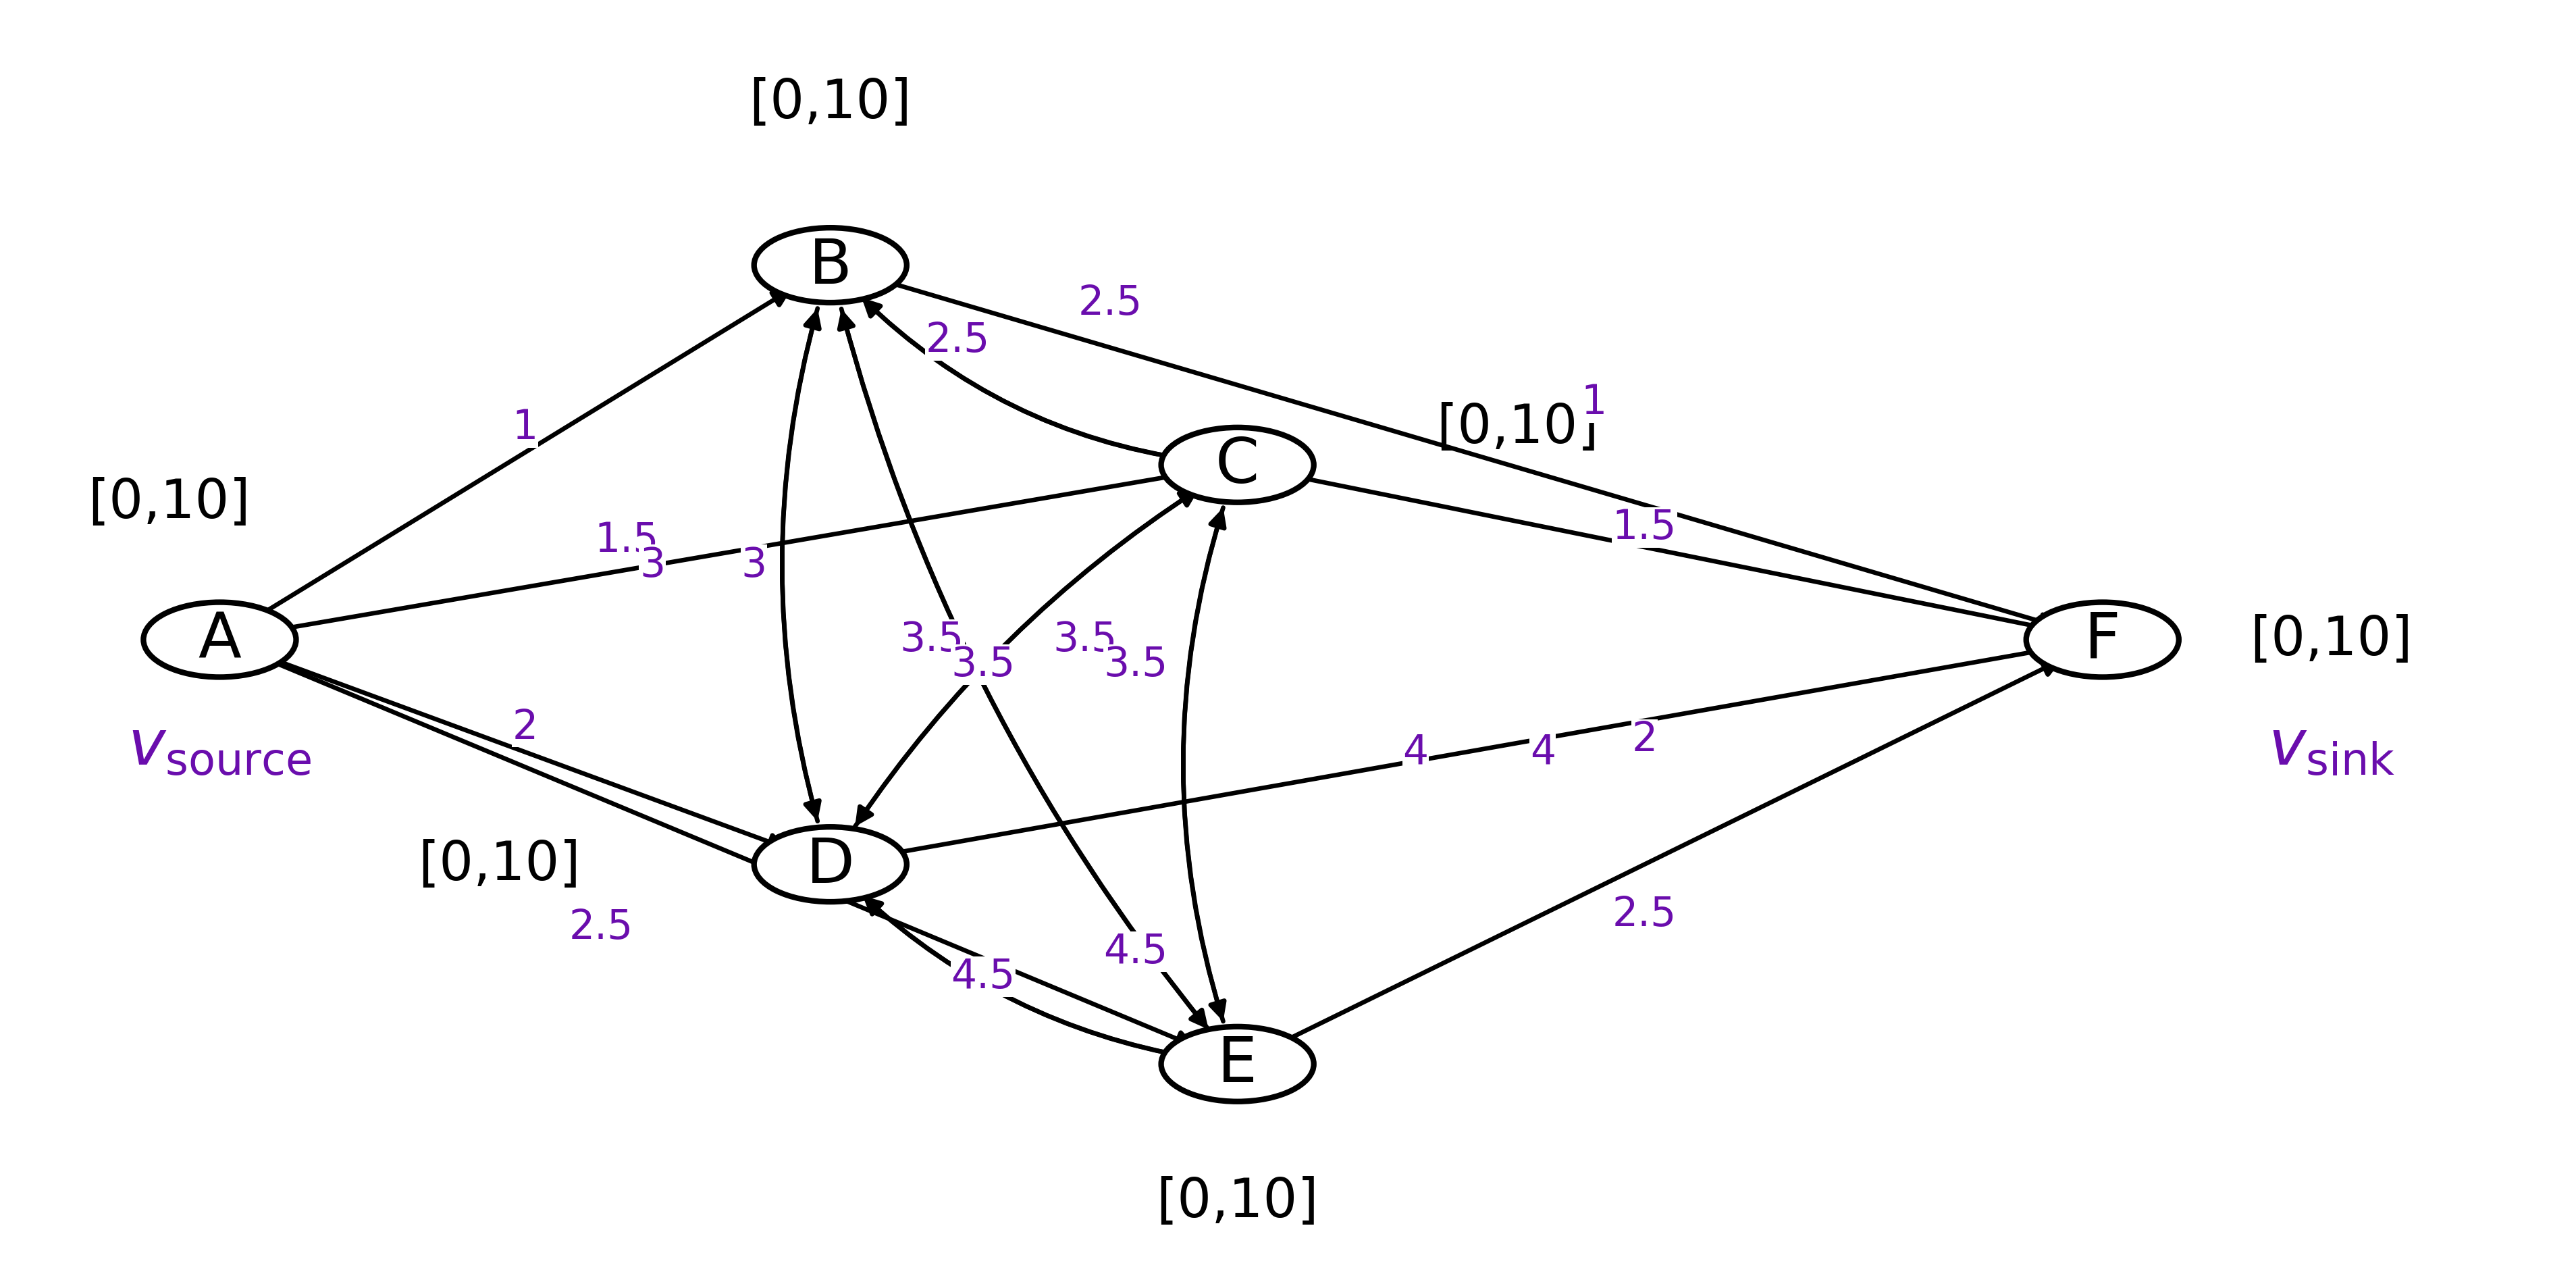

In [5]:
arcs = {
  'A': {'B', 'C', 'D', 'E'},
  'B': {'C', 'D', 'E', 'F'},
  'C': {'B', 'D', 'E', 'F'},
  'D': {'B', 'C', 'E', 'F'},
  'E': {'B', 'C', 'D', 'F'},
  'F': {},
}

resource_cost = {
  'A': {'B': 1.0, 'C': 1.5, 'D': 2.0, 'E': 2.5},
  'B': {'C': 2.5, 'D': 3.0, 'E': 3.5, 'F': 1.0},
  'C': {'B': 2.5, 'D': 3.5, 'E': 4.0, 'F': 1.5},
  'D': {'B': 3.0, 'C': 3.5, 'E': 4.5, 'F': 2.0},
  'E': {'B': 3.5, 'C': 4.0, 'D': 4.5, 'F': 2.5},
  'F': {},
}

costs = {
  'A': {'B': -99.0, 'C': -148.0, 'D': -197.0, 'E': -246.0},
  'B': {'C': -249.0, 'D': -298.0, 'E': -347.0, 'F': -99.0},
  'C': {'B': -249.0, 'D': -349.0, 'E': -398.0, 'F': -148.0},
  'D': {'B': -298.0, 'C': -349.0, 'E': -449.0, 'F': -197.0},
  'E': {'B': -347.0, 'C': -398.0, 'D': -449.0, 'F': -246.0},
  'F': {},
}

lb = {
  'A': 0,
  'B': 0,
  'C': 0,
  'D': 0,
  'E': 0,
  'F': 0,
}

ub = {
  'A': 10,
  'B': 10,
  'C': 10,
  'D': 10,
  'E': 10,
  'F': 10,
}

ng_set = {
  'A': {},
  'B': {},
  'C': {},
  'D': {},
  'E': {},
  'F': {},
}

source = 'A'
sink = 'F'

### 3- Estruturas Base

In [6]:
class RCSP:

  def __init__(self, arcs, resource_cost, costs, lb, ub, ng_set, source, sink):
    self.arcs = arcs
    self.resource_cost = resource_cost
    self.costs = costs
    self.lb = lb
    self.ub = ub
    self.ng_set = ng_set
    self.source = source
    self.sink = sink

    self.M = 100

    # vão ser preenchidos quando você chamar replicate_graph_complete()
    self.new_arcs: Dict[str, Set[str]] = {}
    self.new_costs: Dict[str, Dict[str, Any]] = {}
    self.new_resource_cost: Dict[str, Dict[str, Any]] = {}
    self.new_lb: Dict[str, Any] = {}
    self.new_ub: Dict[str, Any] = {}
    self.rep: Dict[str, list[str]] = {}

  def delta_minus(self, arcs, objective):
    result = []
    for i, v in arcs.items():
      for j in v:
        if j == objective:
          result.append(i)
    return result

  def delta_plus(self, arcs, objective):
    result = []
    for i, v in arcs.items():
      for j in v:
        if i == objective:
          result.append(j)
    return result

  def check_original(self, objective):
    for i,v in self.rep.items():
      for j in v:
        if j == objective:
          return i

  def calculate_clones(self):
    # soma do menor custo de entrada e menor custo de saída por nó
    d = dict()

    for arc in self.arcs:
      if arc == self.source or arc == self.sink:
        continue

      min_in = self.M
      enter = self.delta_minus(self.arcs, arc)
      for i in enter:
        min_in = min(min_in, self.resource_cost[i][arc])

      min_out = self.M
      exit = self.delta_plus(self.arcs, arc)
      for i in exit:
        min_out = min(min_out, self.resource_cost[arc][i])

      d[arc] = max(math.ceil(self.ub[arc] / (min_in + min_out)), 1)

    return d

  from typing import Dict, List, Tuple

  def replicate_graph_complete(self):
    clone_counts = self.calculate_clones()

    # 1) Ordem original dos nós: a ordem de inserção das chaves do dict é estável em Python 3.7+
    nodes: List[str] = list(self.arcs.keys())
    node_order = {n: i for i, n in enumerate(nodes)}  # pra ordenar vizinhos de forma determinística

    # internos na ordem original
    internal = [v for v in nodes if v not in {self.source, self.sink}]

    # mapeia nó original -> lista de réplicas (ou ele mesmo p/ source/sink)
    rep: Dict[str, List[str]] = {self.source: [self.source], self.sink: [self.sink]}
    for v in internal:
      k = clone_counts.get(v, 1)
      rep[v] = [f"{v}{i}" for i in range(1, k + 1)]

    # 2) new_nodes em lista, preservando ordem:
    #    source, depois internos (com suas réplicas), depois sink (se existirem nessa ordem no nodes, melhor respeitar nodes)
    new_nodes: List[str] = []
    for v in nodes:
      new_nodes.extend(rep[v])

    # 3) cria estruturas novas preservando ordem de iteração
    self.new_arcs = {v: [] for v in new_nodes}           # lista para manter ordem dos vizinhos
    self.new_costs = {v: {} for v in new_nodes}
    self.new_resource_cost = {v: {} for v in new_nodes}
    self.new_lb = {}
    self.new_ub = {}
    self.rep = rep

    # bounds (ordem estável)
    for v in nodes:
      for rv in rep[v]:
        self.new_lb[rv] = self.lb[v]
        self.new_ub[rv] = self.ub[v]

    # helper: adiciona aresta preservando ordem e sem duplicar
    def add_arc(ru: str, rv: str, u: str, v: str):
      # evita duplicata mantendo lista (O(d)), mas mantém ordem
      if rv not in self.new_arcs[ru]:
        self.new_arcs[ru].append(rv)
      self.new_costs[ru][rv] = self.costs[u][v]
      self.new_resource_cost[ru][rv] = self.resource_cost[u][v]

    # helper: iteração de vizinhos com ordem determinística
    def iter_neighbors(u: str):
      neigh = self.arcs.get(u, [])
      if isinstance(neigh, (list, tuple)):
        return neigh
      # se for set (ou qualquer iterável sem ordem), ordenar pelo node_order
      return sorted(neigh, key=lambda x: node_order.get(x, 10**9))

    # arestas na ordem dos nós + ordem dos vizinhos
    for u in nodes:
      for v in iter_neighbors(u):
        pairs: List[Tuple[str, str]] = []

        if u == self.source and v not in {self.source, self.sink}:
          pairs = [(self.source, rv) for rv in rep[v]]

        elif v == self.sink and u not in {self.source, self.sink}:
          pairs = [(ru, self.sink) for ru in rep[u]]

        elif u not in {self.source, self.sink} and v not in {self.source, self.sink}:
          pairs = [(ru, rv) for ru in rep[u] for rv in rep[v]]

        else:
          pairs = [(ru, rv) for ru in rep[u] for rv in rep[v]]

        for ru, rv in pairs:
          add_arc(ru, rv, u, v)


In [ ]:
def retrieve_path(model):
  # get only used arcs
  used_arcs = list()
  for var in model.vars:
    if var.name.startswith("x"):
      if var.x == 1:
        used_arcs.append(var.name)

  # get path
  path = ["A"]
  entry = "A"
  while len(used_arcs):
    for name in used_arcs:
      if name.split("x_")[1].startswith(entry):
        entry = name.split("x_")[1].split("_")[1]
        path.append(entry[0])
        used_arcs.remove(name)
        break

  return path

def check_ng_set(rcsp, model):

  path = retrieve_path(model)

  memory = set()

  for node in path:
    if node in memory:
      return False
    removed_nodes = list()
    for known_node in memory:
      if known_node not in rcsp.ng_set[node]:
        removed_nodes.append(known_node)
    for removed_node in removed_nodes:
      memory.remove(removed_node)
    memory.add(node)

  return True

def retrieve_path_cplex(model, solution):
  # get only used arcs
  used_arcs = list()
  for var in model.iter_variables():
    if var.name.startswith("x"):
      if solution.get_value(var) == 1:
        used_arcs.append(var.name)

  # get path
  path = ["A"]
  entry = "A"
  while len(used_arcs):
    for name in used_arcs:
      if name.split("x_")[1].startswith(entry):
        entry = name.split("x_")[1].split("_")[1]
        path.append(entry[0])
        used_arcs.remove(name)
        break

  return path

def check_ng_set_cplex(rcsp, model, solution):

  path = retrieve_path_cplex(model, solution)

  memory = set()

  for node in path:
    if node in memory:
      return False
    removed_nodes = list()
    for known_node in memory:
      if known_node not in rcsp.ng_set[node]:
        removed_nodes.append(known_node)
    for removed_node in removed_nodes:
      memory.remove(removed_node)
    memory.add(node)

  return True

def retrieve_path_gurobi(model):
  # get only used arcs
  used_arcs = list()
  for var in model.getVars():
    if var.VarName.startswith("x") and round(var.X) == 1:
        used_arcs.append(var.VarName)

  # get path
  path = ["A"]
  entry = "A"
  while len(used_arcs):
    for name in used_arcs:
      if name.split("x_")[1].startswith(entry):
        entry = name.split("x_")[1].split("_")[1]
        path.append(entry[0])
        used_arcs.remove(name)
        break

  return path

def check_ng_set_gurobi(rcsp, model):

  path = retrieve_path_gurobi(model)

  memory = set()

  for node in path:
    if node in memory:
      return False
    removed_nodes = list()
    for known_node in memory:
      if known_node not in rcsp.ng_set[node]:
        removed_nodes.append(known_node)
    for removed_node in removed_nodes:
      memory.remove(removed_node)
    memory.add(node)

  return True

### 4- Modelando o Problema

In [8]:
rcsp = RCSP(arcs=arcs, resource_cost=resource_cost, costs=costs, lb=lb, ub=ub, ng_set=ng_set, source=source, sink=sink)
rcsp.replicate_graph_complete()

model = Model(sense=MINIMIZE, solver_name=CBC)
x = {i: {j: model.add_var(var_type=BINARY, name=f"x_{i}_{j}") for j in v} for i, v in rcsp.new_arcs.items()} # x['A1']['B2']
y = {i: model.add_var(var_type=CONTINUOUS, name=f"y_{i}", lb=0.0) for i, v in rcsp.new_arcs.items()} # y['A1']
z = {i: {j: model.add_var(var_type=BINARY, name=f"z_{i}_{j}") for j in rcsp.arcs.keys()} for i in rcsp.new_arcs.keys()} # x['A']['B']


# Lower bound
for i in rcsp.new_arcs:
  model += y[i] >= rcsp.new_lb[i]*xsum(x[j][i] for j in rcsp.delta_minus(rcsp.new_arcs, i)) # não sei se precisa desse somatório aqui

# Upper bound
for i in rcsp.new_arcs:
  model += y[i] <= rcsp.new_ub[i]

# Resources
for i, v in rcsp.new_arcs.items():
  for j in v:
    model += y[j] >= y[i] - rcsp.M*(1 - x[i][j]) + rcsp.new_resource_cost[i][j]

# Only 1 exits
for i in rcsp.new_arcs:
  model += xsum(x[i][j] for j in rcsp.delta_plus(rcsp.new_arcs, i)) <= 1

# Only 1 enters
for j in rcsp.new_arcs:
  model += xsum(x[i][j] for i in rcsp.delta_minus(rcsp.new_arcs, j)) <= 1

# Enters = Exits
for j in rcsp.new_arcs:
  if j == rcsp.source or j == rcsp.sink:
    continue
  model += xsum(x[i][j] for i in rcsp.delta_minus(rcsp.new_arcs, j)) - xsum(x[j][k] for k in rcsp.delta_plus(rcsp.new_arcs, j)) == 0

# Source
model += xsum(x[rcsp.source][j] for j in rcsp.delta_plus(rcsp.new_arcs, rcsp.source)) == 1

# Sink
model += xsum(x[i][rcsp.sink] for i in rcsp.delta_minus(rcsp.new_arcs, rcsp.sink)) == 1

# Replicando nos (acho que não precisa porque o grafo não é completo, já não existem arcos de um nó para suas réplicas)

# Proibindo ciclos
for i, v in rcsp.new_arcs.items():
  for j in v:
    if i == rcsp.source or j == rcsp.sink:
      continue
    model += x[i][j] <= 1 - z[i][rcsp.check_original(j)]

# Proibindo ciclos
for i, v in rcsp.new_arcs.items():
  for j in v:
    if i == rcsp.source or j == rcsp.sink:
      continue
    for k in rcsp.ng_set[rcsp.check_original(j)]:
      model += z[j][k] >= z[i][k] - (1 - x[i][j])

# Proibindo ciclos
for i in rcsp.new_arcs.keys():
  if i == rcsp.source or i == rcsp.sink:
    continue
  model += z[i][rcsp.check_original(i)] == 1

# Objetivo
model.objective = xsum(rcsp.new_costs[i][j]*x[i][j] for i, v in rcsp.new_arcs.items() for j in v)

# save(model, "model_test.lp")
# solve(model)

# model.verbose = 1
# model.max_mip_gap = 0.01
model.store_search_progress_log = True
print("cols:", model.num_cols, "rows:", model.num_rows)
# status = model.optimize(max_seconds=7200)
# print(status, model.num_solutions, model.objective_value if model.num_solutions else None)

model.write("model.lp")
# !cbc model.lp solve -seconds 10 -printingOptions all

cols: 282 rows: 406


In [9]:
model.search_progress_log.log

[]

In [10]:
print(retrieve_path(model))
print(check_ng_set(rcsp, model))

['A']
True


In [11]:
# print("Status = ", status)
# print(f"Solution value  = {model.objective_value:.2f}\n")

# print("Solution:")
# for v in model.vars:
#     print(f"{v.name} = {v.x:.2f}")

In [12]:
# Cplex
# from docplex.mp.model_reader import ModelReader

# mdl = ModelReader.read("model.lp")   # or "model.mps"
# sol = mdl.solve(log_output=True)

# if sol is None:
#     print("No solution (infeasible/unbounded or solve failed).")
# else:
#     print("Objective:", sol.objective_value)

#     # Example: access variable values
#     for v in mdl.iter_variables():
#         if abs(sol.get_value(v)) > 1e-9:
#             print(v.name, sol.get_value(v))

In [13]:
import gurobipy as gp
from gurobipy import GRB

model = gp.read("model.lp")   # or "model.mps"
model.optimize()

status = model.Status

if status in (GRB.INFEASIBLE, GRB.UNBOUNDED, GRB.INF_OR_UNBD):
    print("No solution (infeasible/unbounded or solve failed).")
elif model.SolCount == 0:
    print("Optimization finished, but no feasible solution was found.")
else:
    print("Objective:", model.ObjVal)

    for v in model.getVars():
        if abs(v.X) > 1e-9:
            print(v.VarName, v.X)

Set parameter Username
Set parameter LicenseID to value 2782885
Academic license - for non-commercial use only - expires 2027-02-24
Read LP format model from file model.lp
Reading time = 0.06 seconds
OBJROW: 406 rows, 282 columns, 1520 nonzeros
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 6800H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 406 rows, 282 columns and 1520 nonzeros (Min)
Model fingerprint: 0x5f195f4e
Model has 170 linear objective coefficients
Variable types: 16 continuous, 266 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+02]
  Objective range  [1e+02, 4e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+02]

Found heuristic solution: objective -496.0000000
Presolve removed 192 rows and 98 columns
Presolve time: 0.02s
Presolved: 214 rows, 184 columns, 2274 no

In [14]:
output_filename = "solution_values.txt"

with open(output_filename, "w") as f:
    f.write(f"Objective value: {model.ObjVal}\n")
    f.write("Variable Solutions:\n")

    for v in model.getVars():
        f.write(f"{v.VarName}: {v.X}\n")

print(f"Solution saved to {output_filename}")

Solution saved to solution_values.txt


In [20]:
print(retrieve_path_gurobi(model))
print(check_ng_set_gurobi(rcsp, model))

['A', 'C', 'B', 'C', 'B', 'F']
True
